ИМПОРТ НЕОБХОДИМЫХ БИБЛИОТЕК

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
PROJECT_ROOT = Path('/Users/apch/Pycharmproekti/nn_real_estate')

ПРОВЕРКА ДАННЫХ

In [3]:
df = pd.read_csv('/Users/apch/Pycharmproekti/nn_real_estate/data/processed/dataset_before_fe.csv')
df = df.dropna(how='all')
df['district'] = df['district'].fillna('unknown')
df['material'] = df['material'].fillna('unknown')
print(f"Количество строк: {len(df)}, количество признаков: {len(df.columns)}")
print(f"Признаки: {df.columns}")
df.head()

Количество строк: 4322, количество признаков: 14
Признаки: Index(['rooms', 'adress', 'district', 'year', 'material', 'price',
       'total_area', 'living_area', 'kitchen_area', 'current_floor',
       'max_floor', 'is_ready', 'metro', 'mini_disctrict'],
      dtype='str')


,rooms,adress,district,year,material,price,total_area,living_area,kitchen_area,current_floor,max_floor,is_ready,metro,mini_disctrict
0,1.0,"ул. Красных Зорь, 23Д",Сормовский район,0.0,монолитный железобетон,8699992.0,38.76,12.08,16.62,4.0,16.0,1.0,NaN,NaN
1,2.0,"ул. Маршала Голованова, д. 71",Приокский район,49.0,кирпич,6500000.0,45.50,28.00,7.00,2.0,9.0,1.0,NaN,NaN
2,2.0,"КД Резиденция, дом №2",Советский район,0.0,кирпич,20130935.0,53.50,24.00,12.00,7.0,9.0,1.0,NaN,NaN
3,2.0,NaN,Советский район,NaN,unknown,8350000.0,59.60,NaN,NaN,18.0,19.0,NaN,40.0,м. Горьковская
4,2.0,"ул. Героя Советского Союза Аристархова, д. 1",Советский район,4.0,блок+утеплитель,16850000.0,63.00,28.00,22.00,11.0,15.0,1.0,NaN,NaN


РАСПРЕДЕЛЕНИЕ ВОЗРАСТА ЗДАНИЙ ПО РАЙОНАМ

<Axes: xlabel='district', ylabel='price_mln'>

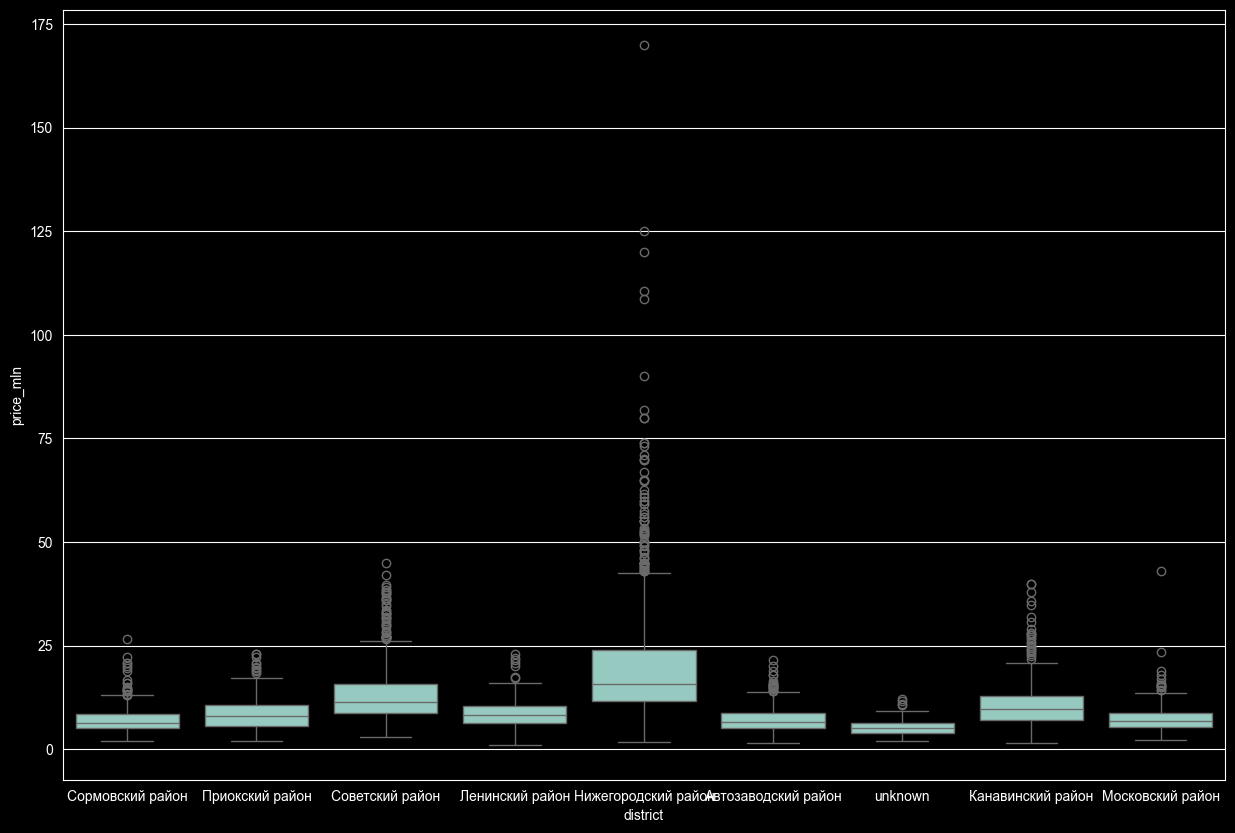

In [4]:
df['price_mln'] = df['price'] / 1_000_000
plt.figure(figsize=(15, 10))
sns.boxplot(x='district', y='price_mln', data=df)

ЛОГАРИФМИРОВАНИЕ ЦЕНЫ

In [8]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = (Q3 - Q1)
upper_bound = Q3 + 1.5 * IQR
print(len(df[df['price'] >= upper_bound]))
print((294 / len(df) * 100))
df['price_log'] = np.log(df['price'])
print(df['price'].median())
print(df['price'].mean())


294
6.802406293382693
9675350.0
12371941.32184174


ПРОВЕРКА МОДЕЛИ

In [6]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
features = ['rooms', 'total_area', 'year', 'district', 'material', 'living_area', 'kitchen_area', 'metro',
            'current_floor', 'max_floor', 'is_ready']
X = df[features]
y = df['price']
y_log = df['price_log']
cat_features = ['district', 'material']

# Split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Модель
model = CatBoostRegressor(iterations=300, cat_features=cat_features, verbose=50, random_seed=42)
model.fit(X_train, y_train_log)
# Оценка
pred_log = model.predict(X_test)
pred_price = np.exp(pred_log)
y_test_price = np.exp(y_test_log)
r2 = model.score(X_test, y_test_log)
print(f"R²: {r2:.4f}")
from sklearn.metrics import r2_score
r2_real = r2_score(y_test_price, pred_price)
print(f"R² на реальной цене: {r2_real:.4f}")
# Важность признаков
fi = model.get_feature_importance()
for name, imp in zip(features, fi):
    print(f"{name}: {imp:.4f}")
# MAE — средняя абсолютная ошибка в рублях
mae = mean_absolute_error(y_test_price, pred_price)
# MAPE — средняя абсолютная ошибка в процентах
mape = mean_absolute_percentage_error(y_test_price, pred_price) * 100
print(f"MAE: {mae:,.0f} ₽")
print(f"MAPE: {mape:.2f}%")

Learning rate set to 0.132555
0:	learn: 0.5470614	total: 56.2ms	remaining: 16.8s
50:	learn: 0.1980359	total: 108ms	remaining: 529ms
100:	learn: 0.1705861	total: 152ms	remaining: 300ms
150:	learn: 0.1563622	total: 196ms	remaining: 193ms
200:	learn: 0.1455211	total: 241ms	remaining: 119ms
250:	learn: 0.1372120	total: 282ms	remaining: 55.1ms
299:	learn: 0.1295162	total: 327ms	remaining: 0us
R²: 0.9078
R² на реальной цене: 0.8243
rooms: 1.7012
total_area: 35.4105
year: 5.9337
district: 20.7342
material: 2.9261
living_area: 1.8587
kitchen_area: 9.0147
metro: 3.1784
current_floor: 2.1549
max_floor: 15.4258
is_ready: 1.6618
MAE: 1,841,644 ₽
MAPE: 12.82%


In [7]:
output_path = PROJECT_ROOT / 'data' / 'processed' / 'dataset_before_fe.csv'
df.to_csv(output_path, index=False)